Accuracy: 0.93


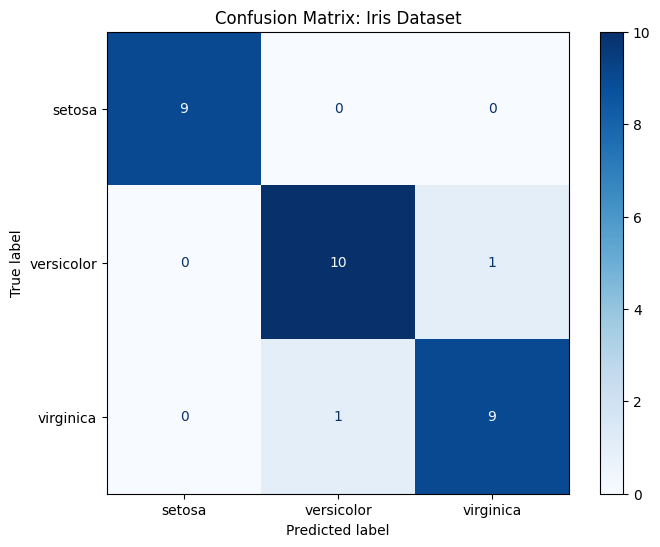

In [90]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Dataset setup
data = load_iris()
X = data.data
y = data.target

# 2. Split (using your random_state 41)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# 3. Model initialization and training
# max_iter increased to ensure convergence on this dataset
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. Predictions
predictions = model.predict(X_test)

# 5. Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

# 6. CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Iris Dataset')
plt.show()

0.5558915986952425


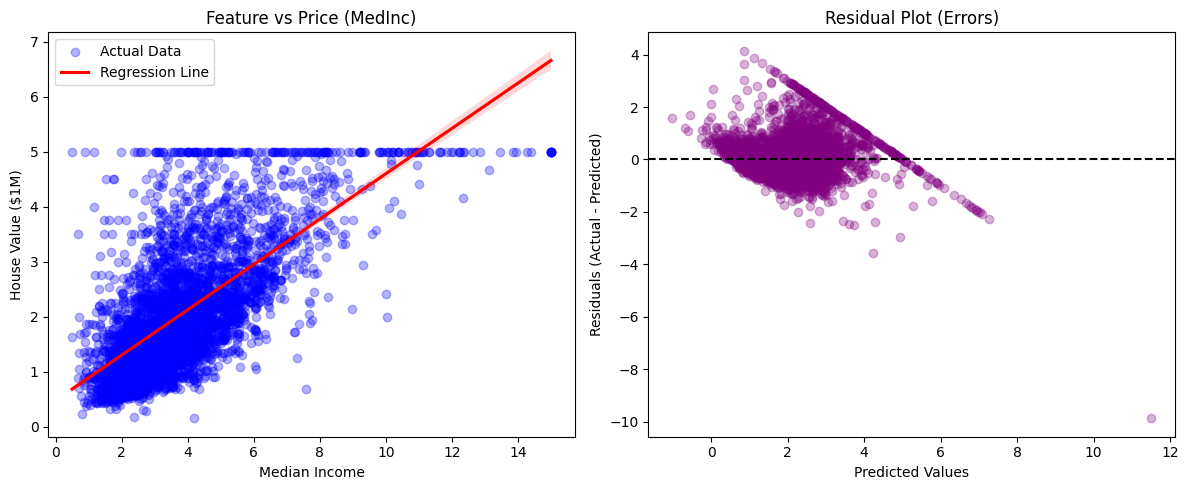

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Load Data
housing = fetch_california_housing()


## Applicare rimozione outlier con z score = 3


X = housing.data
y = housing.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)

print(mse)

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($1M)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

Rows removed: 482
Mean Squared Error: 0.4534


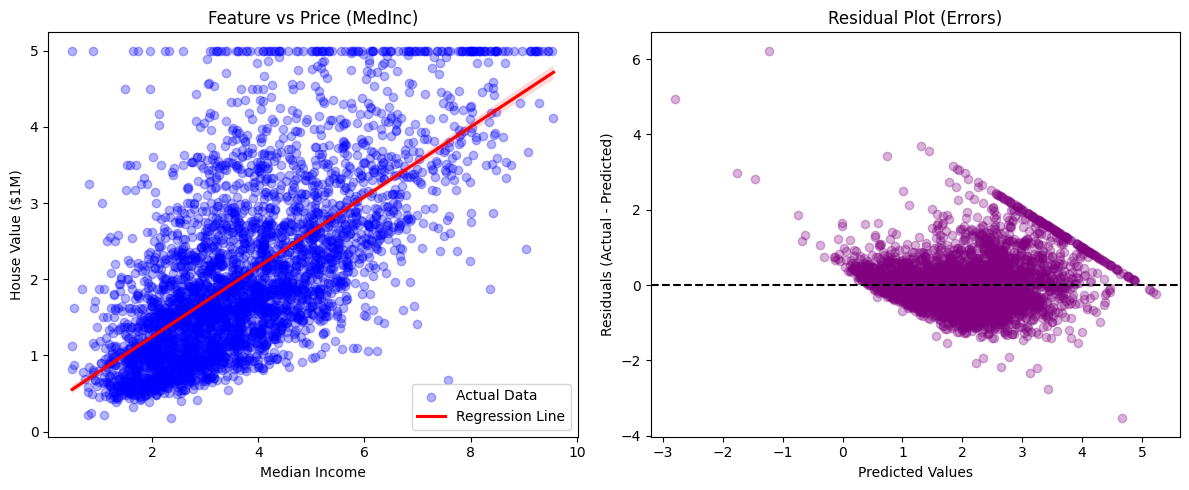

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from scipy import stats
import pandas as pd

# 1. Load Data
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target to the dataframe so it stays synchronized during filtering
df_housing['MedHouseVal'] = housing.target

## Outlier removal function (stays the same)
def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    z_scores = np.abs(stats.zscore(df_clean[columns]))
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# 2. Apply filtering
df_zscore = remove_outliers_zscore(df_housing, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Rows removed: {len(df_housing) - len(df_zscore)}")

# 3. Redefine X and y from the cleaned DataFrame
# X is everything except the target; y is just the target
X = df_zscore.drop(columns=['MedHouseVal']).values 
y = df_zscore['MedHouseVal'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($1M)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [93]:
import seaborn as sns

# Load the built-in titanic dataset
df = sns.load_dataset('titanic')

# Display the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Da fare

- ripulire il dataset
- convertire categorie in numeri
- rimuovere outlier con z-score 3
- feature engineering
- normalizzare
- applicare logistic regression

## Pulizia dei dati
1. Rimozione di dati di colonna class
2. Rimozione dei NaN

In [94]:
# Rimozione dati di colonna class
df = df.drop(columns=['class', 'who', 'embarked', 'alive'])

# Rimozione dei NaN dalla colonna deck
# df = df.dropna(subset=['deck'])

# Sostituzione dei NaN con la modalità più frequente (per la colonna deck)
most_frequent_deck = df['deck'].mode()[0]
df['deck'] = df['deck'].fillna(most_frequent_deck)

df.info()
df.describe()

print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   adult_male   891 non-null    bool    
 8   deck         891 non-null    category
 9   embark_town  889 non-null    str     
 10  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(2)
memory usage: 58.8 KB
   survived  pclass     sex   age  sibsp  parch     fare  adult_male deck  \
0         0       3    male  22.0      1      0   7.2500        True    C   
1         1       1  female  38.0      1      0  71.2833       False    C   
2         1       3  female  26.0  

## `Convertire` categorie in numeri

In [95]:
# Conversione delle categorie in numeri
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embark_town'] = df['embark_town'].map({'Southampton': 0, 'Cherbourg': 1, 'Queenstown': 2})
df['deck'] = df['deck'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'T': 7})
print(df.head())

   survived  pclass  sex   age  sibsp  parch     fare  adult_male deck  \
0         0       3    0  22.0      1      0   7.2500        True    2   
1         1       1    1  38.0      1      0  71.2833       False    2   
2         1       3    1  26.0      0      0   7.9250       False    2   
3         1       1    1  35.0      1      0  53.1000       False    2   
4         0       3    0  35.0      0      0   8.0500        True    2   

   embark_town  alone  
0          0.0  False  
1          1.0  False  
2          0.0   True  
3          0.0  False  
4          0.0   True  


## `Rimozione` outlier con z-score 3

In [96]:
# Rimozione outlier con z score = 3
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
df_zscore = remove_outliers_zscore(df, ['age', 'fare', 'parch', 'sibsp'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

Righe rimosse con Z-Score: 891


## `Feature Engineering`

In [97]:
# Feature Engineering: creazione di una nuova colonna "family_size"
df_zscore['family_size'] = df_zscore['parch'] + df_zscore['sibsp']
print(df_zscore['family_size'].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
#precision recall f1-score support
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

#albero decisionale sul df di titanic che stavo usando prima, con target "survived" e tutte le altre colonne come feature
X = df_zscore.drop(columns=['survived']).values
y = df_zscore['survived'].values

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Addestramento del modello XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predizione
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))